In [7]:
import glob, os, subprocess
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord

In [8]:
def reformat_pm_catalog(filename):

    """
    Reformats the proper motion catalogues from the Hubble Space Telescope Atlases of
    Cluster Kinematics (HACKS) into a tab separared value file

    Data access : https://archive.stsci.edu/hlsp/hacks
    
    Args:
        filename: the proper motion file name  for the cluster
        
    Returns:
        RA, Dec: pd dataframes for coordinates matching ID
        
    HACKS original pm file before reformatting
    # -----------------------------------------------------------------------------------------------------------------
    #
    # NGC7078 - PROPER-MOTION CATALOG
    #
    # -----------------------------------------------------------------------------------------------------------------
    # Please cite the following paper when using this catalog:
    # Libralato et al. (2022, ApJ, XX, YYY)
    # DOI: 10.17909/jpfd-2m08
    # "HACKS - The HST UV Legacy Survey of Galactic GCs. XXIII"
    # -----------------------------------------------------------------------------------------------------------------
    # Cluster center ~ (11500,9500) WFC3/UVIS pixel
    # Positions at reference epoch (yr) ~ 2009
    # Absolute proper-motion zero-point = (-0.645+/-0.018,-3.803+/-0.019) mas/yr
    # -----------------------------------------------------------------------------------------------------------------
    # Col.  1: Right Ascension (in deg)
    # Col.  2: Declination (in deg)
    # Col.  3: X master-frame position (in pixel; pixel scale of 40 mas/pixel)
    # Col.  4: Y master-frame position (in pixel; pixel scale of 40 mas/pixel)
    # Col.  5: Corrected proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col.  6: Error on the corrected proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col.  7: Corrected proper motion along Declination (in mas/yr)
    # Col.  8: Error on the corrected proper motion along Declination (in mas/yr)
    # Col.  9: Reduced chi2 of the proper-motion fit along Right Ascension cos(Declination)
    # Col. 10: Reduced chi2 of the proper-motion fit along Declination
    # Col. 11: Number of exposures initially considered in the proper-motion fit
    # Col. 12: Number of exposures actually used in the proper-motion fit
    # Col. 13: Temporal baseline of the proper-motion fit (in yr)
    # Col. 14: Raw proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col. 15: Error on the raw proper motion along Right Ascension cos(Declination) (in mas/yr)
    # Col. 16: Raw proper motion along Declination (in mas/yr)
    # Col. 17: Error on the raw proper motion along Declination (in mas/yr)
    # Col. 18: Flags that tells if the proper motion is a-posteriori corrected for systematics
    # Col. 19: ID number of the source
    # -----------------------------------------------------------------------------------------------------------------
    # Notes:
    #        (1) The ID number of a source is the same in all catalogs for the same cluster
    #        (2) (X,Y) positions are defined at a specific epoch about halfway between the first and last
    #            epochs used in the proper-motion computation. The reference epoch is provided above
    #        (3) The flag in column 18 is set to 1 if the proper-motion is a-posteriori corrected for 
    #            high-frequency systematics, and 0 if otherwise
    # -----------------------------------------------------------------------------------------------------------------

    """
    
    # global_offset_dec = 0.15/3600
    # global_offset_ra = -0.03/3600
    
    print("Executing function")

    # Extract the column names and use them as colnames for pandas df
    columns = []
    colnames = ['Col']
    with open(filename) as f:
        for line in f.readlines():
            if any(colname in line for colname in colnames ):
                line = line.replace("#", "").replace("Col.", "").strip()
                line = ''.join((char for char in line if not char.isdigit())).replace(":","")
                # print(line)
                columns.append(line)
        
    # Extract the data from the file and create a dataframe
    
    with open(filename, "r") as f:
        lines = [line.strip() for line in f.readlines() if not line.startswith('#')]
        
    data = [line.split() for line in lines]
    df = pd.DataFrame(data,columns = columns)
    
    
    
    # Drop some columns -- keeping the ID, pmra, pmdec and their errors
    
    df_dropped_columns = df.drop(df.columns[[2, 3, *range(8, 18)]], axis=1)
    
    # Rename the columns and re-index so that ID comes first
    
    old_column_names = df_dropped_columns.columns.tolist()
    new_column_names = {'Col.  1': 'RA', 'Col.  2': 'Dec', 'Col.  3': 'PMRA', 'Col.  4': 'e_PMRA',
                        'Col.  5': 'PMDec', 'Col.  6': 'e_PMDec','Col. 7': 'ID'}
    column_rename_dict = dict(zip(old_column_names, new_column_names.values()))
    df_dropped_columns.rename(columns=column_rename_dict,inplace=True)
    
    column_names = list(column_rename_dict.values())
    reindexed_columns = column_names[-1:] + column_names[:-1] # move ID to first column
    
    df_reindexed = df_dropped_columns[reindexed_columns]
    
    # print(df_reindexed)

    return df_reindexed

    
    


In [9]:
filename = '/raid1/scratch/kelvinw/hacks_data/ngc7078/hlsp_hacks_hst_acs-wfc3_ngc7078_multi_v1.0_pm-catalog.txt'
new_df = reformat_pm_catalog(filename)

Executing function


In [14]:
print(new_df.columns)
df_ra = new_df['RA'].to_numpy().astype(float)
df_dec = new_df['Dec'].to_numpy().astype(float)
pmra = new_df['PMRA'].to_numpy().astype(float)
pmdec = new_df['PMDec'].to_numpy().astype(float)
pmra_err = new_df['e_PMRA'].to_numpy().astype(float)
pmdec_err = new_df['e_PMDec'].to_numpy().astype(float)

Index(['ID', 'RA', 'Dec', 'PMRA', 'e_PMRA', 'PMDec', 'e_PMDec'], dtype='object')


In [62]:
import astropy.coordinates as coord
import astropy.units as u
from astropy.time import Time


"""
Monte Carlo error propagation -- the 
The propagation of proper motion is done using a monte carlo scheme

1. The proper motions are assumed to be normally distributed and N samples of the proper motion are
    drawn from the normal distribution with a mean given by the proper motion and a std given by the error

2. A monte carlo simulation is then done over the range of N samples, to generate positions for each i sample.
    The coordinates are then propagated using applyspacemotion for each sampled point to form a distribution of the final propagated position.

3. The std deviation of the distribution is assumed to be the uncertainty in the position

"""

hacks_epoch = '2009-01-01'
gaia_epoch = '2016-01-01'

np.random.seed(1234)
N_samples = 1000
radial_velocity = 50 
distance = 10.4

ra= df_ra[0:9]
dec = df_dec[0:9]
pmra_error = pmra_err[0:9]
pmdec_error = pmdec_err[0:9]

### Assuming the proper motions are normally distributed with mean ra or dec and std pm_err
### Simulate 1000 samples

## Storing the current position uncertainties

# monte_carlo_ra = np.zeros((N_samples,len(ra)))*u.deg
# print(monte_carlo_ra.shape)


all_current_positions =[]
all_current_positions_ra = []
all_current_positions_dec = []

for i in range(len(ra)):
    ## creating a sample of pmra and pmdec
    pmra_samples = np.random.normal(pmra[i],pmra_error[i],N_samples)
    pmdec_samples = np.random.normal(pmdec[i],pmdec_error[i],N_samples)
    print(pmra_samples.shape)
    # print(len(np.linspace(0,1000,1000)))
    # plt.plot(np.linspace(0,1,1000),pmra_samples)

    ## Transform each sampled point coordinates and do epoch propagation

    current_position_for_source =[]
    current_positions_ra = []
    current_positions_dec = []

    for sample in range(N_samples):
        sampled_coord = coord.SkyCoord(ra=ra[i]*u.degree,dec=dec[i]*u.degree,pm_ra_cosdec=pmra_samples[sample]*u.mas/u.yr,
                                    pm_dec = pmdec_samples[sample]*u.mas/u.yr,radial_velocity=radial_velocity*u.km/u.s,
                                    distance = distance*u.kpc,frame='icrs',obstime=Time(hacks_epoch))
        
        propagated_coord = sampled_coord.apply_space_motion(new_obstime=Time(gaia_epoch))
        current_positions_ra.append(propagated_coord.ra.deg)
        current_positions_dec.append(propagated_coord.dec.deg)

        current_position_for_source.append(propagated_coord)
    all_current_positions_ra.append(current_positions_ra)
    all_current_positions_dec.append(current_positions_dec)
    all_current_positions.append(current_position_for_source)
    




(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)


(array([  5.,  11.,  63., 145., 219., 238., 187.,  85.,  32.,  15.]),
 array([322.49114682, 322.49114699, 322.49114716, 322.49114733,
        322.4911475 , 322.49114766, 322.49114783, 322.491148  ,
        322.49114817, 322.49114834, 322.4911485 ]),
 <BarContainer object of 10 artists>)

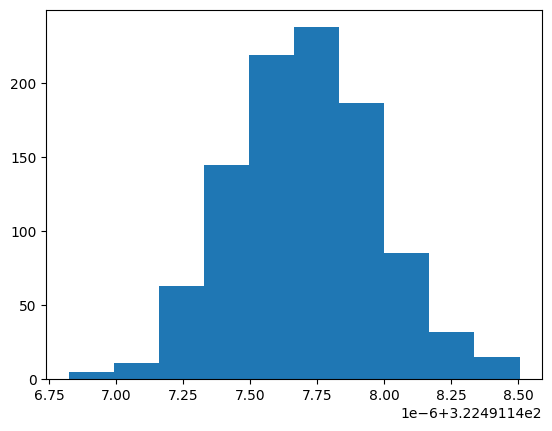

In [68]:
plt.hist(current_positions_ra)

In [70]:
np.mean(current_positions_ra)

322.4911477051191

In [72]:
a = np.std(current_positions_ra)


KeyboardInterrupt: 

In [ ]:
a